In [1]:
import sys
import os
import torch
from torch.utils.data import DataLoader
from torchvision import transforms
import matplotlib.pyplot as plt
import numpy as np

sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))
from preprocessing.load_datasets import load_ucsd_ped2
from preprocessing.video_dataset import VideoFrameDataset

DATASET_ROOT = "../data/UCSD_Anomaly_Dataset/UCSD_Anomaly_Dataset.v1p2"


In [2]:
train_videos, test_videos = load_ucsd_ped2(DATASET_ROOT)

print("Train video folders:", len(train_videos))
print("Test video folders:", len(test_videos))


Train video folders: 16
Test video folders: 24


In [3]:
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),  # converts to [0,1]
])


In [4]:
train_dataset = VideoFrameDataset(train_videos, transform=transform)

print("Total training frames:", len(train_dataset))


Total training frames: 2550


In [5]:
train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=0  # set to 0 on Windows
)


In [6]:
batch = next(iter(train_loader))
print("Batch shape:", batch.shape)


Batch shape: torch.Size([16, 3, 128, 128])


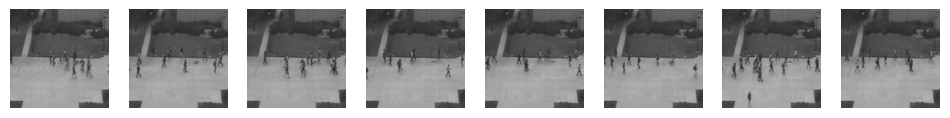

In [7]:
def show_batch(images, num=8):
    plt.figure(figsize=(12, 4))
    for i in range(num):
        img = images[i].permute(1, 2, 0).numpy()  # CHW → HWC
        plt.subplot(1, num, i+1)
        plt.imshow(img)
        plt.axis("off")
    plt.show()

show_batch(batch, num=8)
